<a href="https://colab.research.google.com/github/akshudurairaj/Applied-Machine-Learning/blob/main/QUESTIONS__AML_REGRESSION_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question-1:

Create a dataset containing temperature and electricity consumption.
Train a simple linear regression model.
Divide the data into training and testing sets.
Print the slope and intercept.
Calculate MAE, MSE, RMSE, and (R^2).
Plot the regression line.
Plot residuals.
Add another input feature and train a multiple regression model.
Compare simple and multiple regression performance.
Investigate the effect of adding an outlier.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    "Temperature": [15, 18, 20, 22, 25, 28, 30, 32, 35, 38],
    "Electricity": [120, 135, 145, 160, 175, 195, 210, 230, 250, 275],
    "Humidity": [30, 35, 40, 42, 45, 50, 55, 60, 65, 70]
}

df = pd.DataFrame(data)

print(df)


   Temperature  Electricity  Humidity
0           15          120        30
1           18          135        35
2           20          145        40
3           22          160        42
4           25          175        45
5           28          195        50
6           30          210        55
7           32          230        60
8           35          250        65
9           38          275        70


In [2]:
from sklearn.model_selection import train_test_split

X = df[["Temperature"]]
y = df["Electricity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)


LinearRegression()

In [4]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)


Slope: 6.767068273092368
Intercept: 11.114457831325325


In [5]:
y_pred = model.predict(X_test)

print("Actual:", y_test.values)
print("Predicted:", y_pred)

Actual: [250 135]
Predicted: [247.96184739 132.92168675]


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 2.0582329317269057
MSE: 4.236726020548047
RMSE: 2.0583308821829513
R²: 0.9987185705797964


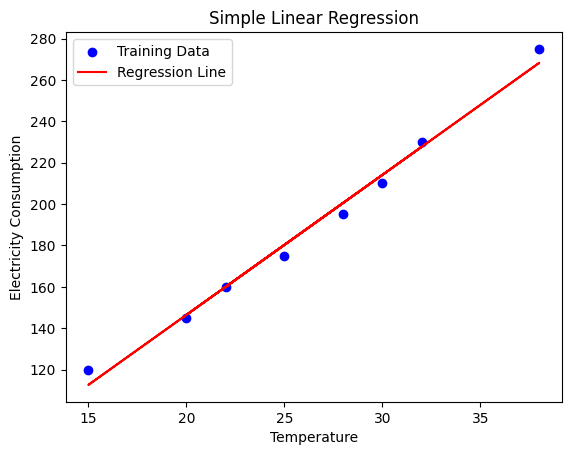

In [9]:
plt.scatter(X_train, y_train, color="blue", label="Training Data")

plt.plot(
    X_train,
    model.predict(X_train),
    color="red",
    label="Regression Line"
)

plt.xlabel("Temperature")
plt.ylabel("Electricity Consumption")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()


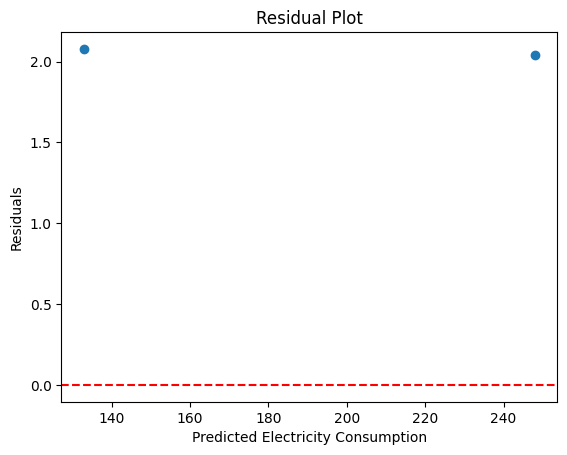

In [10]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Electricity Consumption")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


In [12]:
X = df[["Temperature", "Humidity"]]
y = df["Electricity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)


LinearRegression()

In [14]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)


Slope: 2.635220125786163
Intercept: 1.2358490566037972


In [15]:
y_pred = model.predict(X_test)

print("Actual:", y_test.values)
print("Predicted:", y_pred)


Actual: [250 135]
Predicted: [250.44968553 133.19811321]


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 1.125786163521994
MSE: 1.7245065464182274
RMSE: 1.3132046856519464
R²: 0.9994784101182856


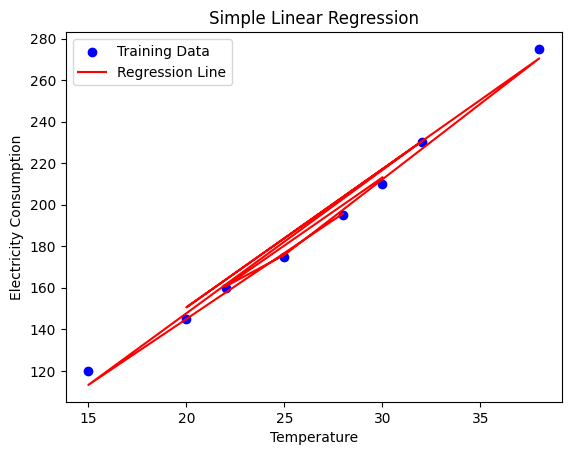

In [20]:
plt.scatter(
    X_train["Temperature"],
    y_train,
    color="blue",
    label="Training Data"
)

plt.plot(
    X_train["Temperature"],
    model.predict(X_train),
    color="red",
    label="Regression Line"
)

plt.xlabel("Temperature")
plt.ylabel("Electricity Consumption")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()



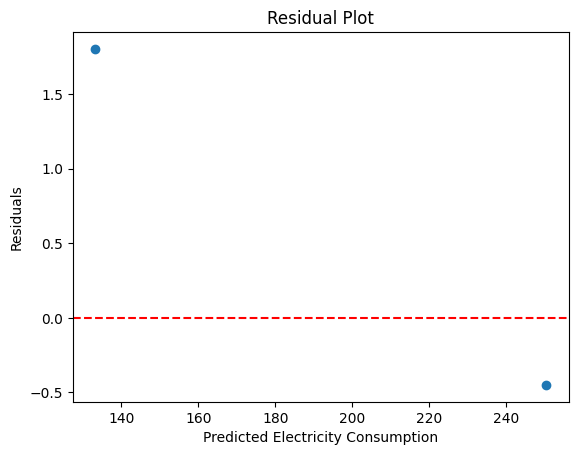

In [21]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Electricity Consumption")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


In [22]:
X = df[["Temperature", "Humidity"]]
y = df["Electricity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [23]:
multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)


LinearRegression()

In [24]:
y_pred_multiple = multiple_model.predict(X_test)


In [25]:
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print("Multiple Regression Results")
print("MAE:", mae_multiple)
print("MSE:", mse_multiple)
print("RMSE:", rmse_multiple)
print("R²:", r2_multiple)


Multiple Regression Results
MAE: 1.125786163521994
MSE: 1.7245065464182274
RMSE: 1.3132046856519464
R²: 0.9994784101182856


In [26]:
comparison = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "MAE": [mae, mae_multiple],
    "MSE": [mse, mse_multiple],
    "RMSE": [rmse, rmse_multiple],
    "R²": [r2, r2_multiple]
})

print(comparison)


                        Model       MAE       MSE      RMSE        R²
0    Simple Linear Regression  1.125786  1.724507  1.313205  0.999478
1  Multiple Linear Regression  1.125786  1.724507  1.313205  0.999478


In [27]:
df_outlier = df.copy()

df_outlier.loc[len(df_outlier)] = [50, 600, 75]

print(df_outlier)


    Temperature  Electricity  Humidity
0            15          120        30
1            18          135        35
2            20          145        40
3            22          160        42
4            25          175        45
5            28          195        50
6            30          210        55
7            32          230        60
8            35          250        65
9            38          275        70
10           50          600        75


In [28]:
X_outlier = df_outlier[["Temperature"]]
y_outlier = df_outlier["Electricity"]

model_outlier = LinearRegression()

model_outlier.fit(X_outlier, y_outlier)

print("Original slope:", model.coef_[0])
print("New slope with outlier:", model_outlier.coef_[0])

print("Original intercept:", model.intercept_)
print("New intercept with outlier:", model_outlier.intercept_)


Original slope: 2.635220125786163
New slope with outlier: 12.006009190526687
Original intercept: 1.2358490566037972
New intercept with outlier: -114.80735242135023


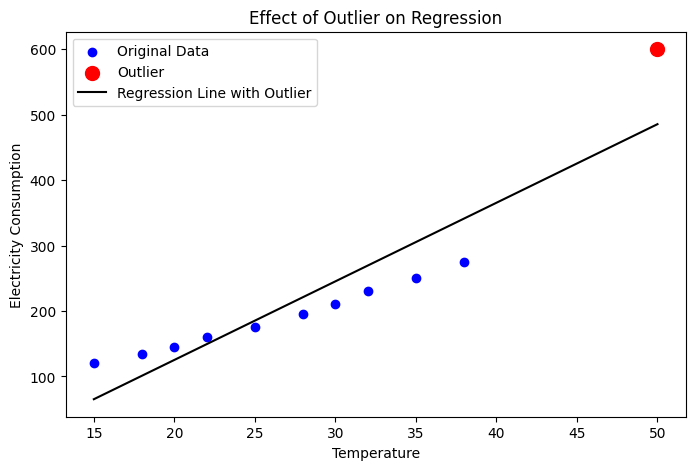

In [29]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Temperature"],
    df["Electricity"],
    color="blue",
    label="Original Data"
)

plt.scatter(
    50,
    600,
    color="red",
    s=100,
    label="Outlier"
)

plt.plot(
    df_outlier["Temperature"],
    model_outlier.predict(X_outlier),
    color="black",
    label="Regression Line with Outlier"
)

plt.xlabel("Temperature")
plt.ylabel("Electricity Consumption")
plt.title("Effect of Outlier on Regression")
plt.legend()
plt.show()


Question-2:
# Create the dataset
data = {
    'Hours_Studied': [2, 4, 6, 8, 10],
    'Classes_Attended': [3, 4, 5, 6, 8],
    'Final_Score': [65, 70, 75, 85, 95]
}

Use Ordinary Least Squares (OLS) model
Predict final score for a new student who studied 7 hours and attended 5 classes




In [30]:
# Import libraries
import pandas as pd
import statsmodels.api as sm

# Create the dataset
data = {
    'Hours_Studied': [2, 4, 6, 8, 10],
    'Classes_Attended': [3, 4, 5, 6, 8],
    'Final_Score': [65, 70, 75, 85, 95]
}

df = pd.DataFrame(data)

# Independent variables
X = df[['Hours_Studied', 'Classes_Attended']]

# Dependent variable
y = df['Final_Score']

# Add intercept
X = sm.add_constant(X)

# Create OLS model
model = sm.OLS(y, X).fit()

# Display model results
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            Final_Score   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     76.33
Date:                Tue, 08 Sep 2026   Prob (F-statistic):             0.0129
Time:                        11:13:23   Log-Likelihood:                -8.1084
No. Observations:                   5   AIC:                             22.22
Df Residuals:                       2   BIC:                             21.05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               47.5000      5.303  

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [31]:
# New student's data
new_student = pd.DataFrame({
    'const': [1],
    'Hours_Studied': [7],
    'Classes_Attended': [5]
})

# Prediction
prediction = model.predict(new_student)

print("Predicted Final Score:", prediction.iloc[0])


Predicted Final Score: 77.75


In [32]:
print("Intercept:", model.params['const'])
print("Hours coefficient:", model.params['Hours_Studied'])
print("Classes coefficient:", model.params['Classes_Attended'])


Intercept: 47.49999999999997
Hours coefficient: 0.7499999999999895
Classes coefficient: 5.000000000000021


In [33]:
print(model.predict(pd.DataFrame({
    'const': [1],
    'Hours_Studied': [7],
    'Classes_Attended': [5]
})))


0    77.75
dtype: float64


Question-3:

Student performance prediction

Problem statement: Develop a multiple linear regression model to predict students’ final marks.

Suggested variables

Study hours per week
Attendance percentage
Assignment average
Internal examination mark
Sleep duration
Final mark

Tasks

Import the dataset.
Perform descriptive analysis.
Check missing values.
Visualize correlations.
Separate inputs and output.
Split the data into training and testing sets.
Train a multiple linear regression model.
Evaluate it using MAE, RMSE, \(R^2\), and adjusted \(R^2\).
Plot actual versus predicted marks.
Examine residuals.
Interpret the coefficients.
Discuss the model’s limitations.

Expected deliverables

Python program or Jupyter Notebook
Dataset
Graphs
Evaluation results
Interpretation of coefficients
Conclusion and limitations

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [35]:
data = {
    'Study_Hours': [5, 8, 10, 12, 15, 18, 20, 22, 25, 28,
                    6, 9, 13, 16, 19, 21, 24, 27, 30, 14],

    'Attendance': [65, 70, 75, 80, 85, 90, 92, 95, 96, 98,
                   68, 73, 82, 86, 89, 93, 94, 97, 99, 84],

    'Assignment_Avg': [55, 60, 65, 70, 75, 78, 82, 85, 90, 92,
                        58, 63, 72, 76, 80, 84, 87, 91, 95, 74],

    'Internal_Mark': [50, 55, 60, 65, 70, 75, 78, 82, 88, 90,
                      52, 58, 67, 72, 76, 80, 85, 89, 93, 68],

    'Sleep_Hours': [5, 6, 6, 7, 7, 7, 8, 8, 8, 7,
                    5, 6, 7, 7, 8, 8, 8, 7, 8, 6],

    'Final_Mark': [55, 62, 68, 72, 78, 82, 86, 90, 94, 96,
                   58, 65, 74, 79, 83, 87, 91, 93, 97, 76]
}

df = pd.DataFrame(data)

df.head()


,Study_Hours,Attendance,Assignment_Avg,Internal_Mark,Sleep_Hours,Final_Mark
0,5,65,55,50,5,55
1,8,70,60,55,6,62
2,10,75,65,60,6,68
3,12,80,70,65,7,72
4,15,85,75,70,7,78


In [37]:
df.describe()
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     20 non-null     int64
 1   Attendance      20 non-null     int64
 2   Assignment_Avg  20 non-null     int64
 3   Internal_Mark   20 non-null     int64
 4   Sleep_Hours     20 non-null     int64
 5   Final_Mark      20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


In [39]:
df.isnull().sum()







,0
Study_Hours,0
Attendance,0
Assignment_Avg,0
Internal_Mark,0
Sleep_Hours,0
Final_Mark,0


In [40]:
print("Total missing values:", df.isnull().sum().sum())


Total missing values: 0


In [41]:
correlation = df.corr()

print(correlation)


                Study_Hours  Attendance  Assignment_Avg  Internal_Mark  \
Study_Hours        1.000000    0.972907        0.992461       0.995906   
Attendance         0.972907    1.000000        0.990960       0.987005   
Assignment_Avg     0.992461    0.990960        1.000000       0.998534   
Internal_Mark      0.995906    0.987005        0.998534       1.000000   
Sleep_Hours        0.807633    0.869119        0.843806       0.838042   
Final_Mark         0.986508    0.994901        0.997087       0.995878   

                Sleep_Hours  Final_Mark  
Study_Hours        0.807633    0.986508  
Attendance         0.869119    0.994901  
Assignment_Avg     0.843806    0.997087  
Internal_Mark      0.838042    0.995878  
Sleep_Hours        1.000000    0.861822  
Final_Mark         0.861822    1.000000  


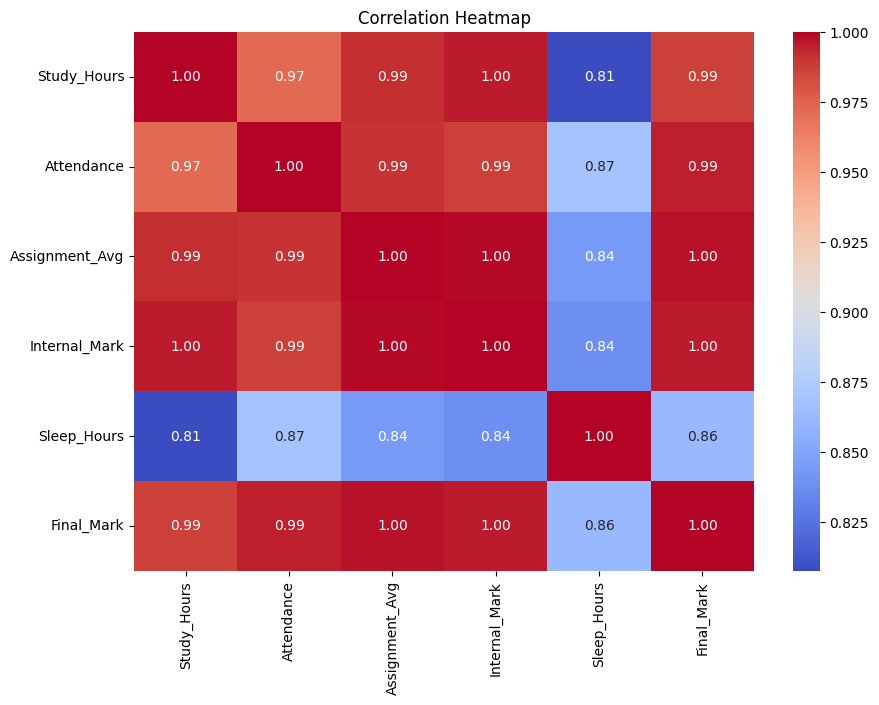

In [42]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [45]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (4, 3)
Testing data: (1, 3)


In [46]:
model = LinearRegression()

model.fit(X_train, y_train)


LinearRegression()

In [47]:
y_pred = model.predict(X_test)

print("Actual values:")
print(y_test.values)

print("\nPredicted values:")
print(y_pred)


Actual values:
[70]

Predicted values:
[70.71428571]


In [48]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 0.7142857142857224
RMSE: 0.7142857142857224
R²: nan


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [49]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R²:", adjusted_r2)


Adjusted R²: nan


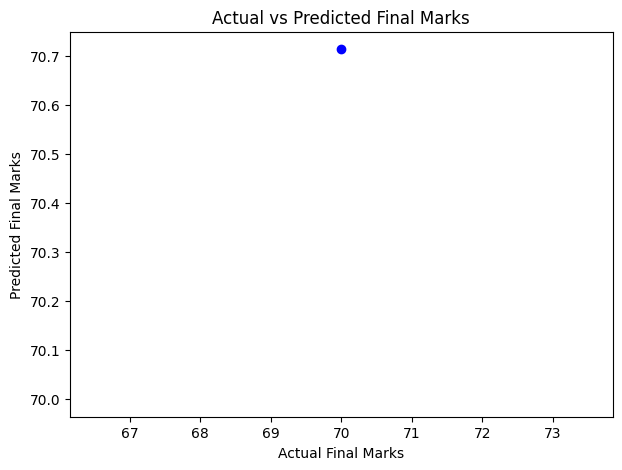

In [50]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, color="blue")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Actual vs Predicted Final Marks")

plt.show()


In [51]:
residuals = y_test - y_pred

print(residuals)


1   -0.714286
Name: Final_Score, dtype: float64


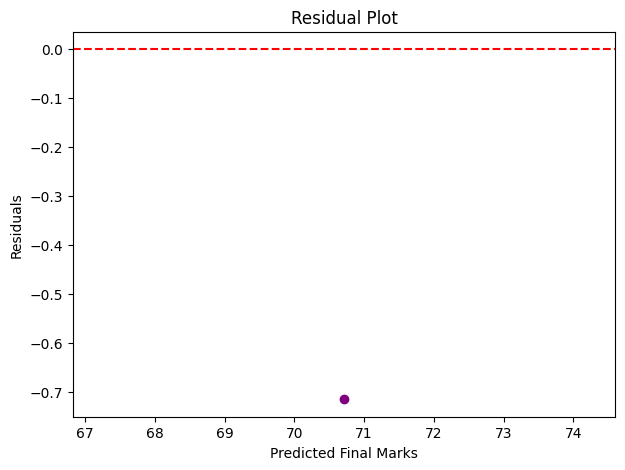

In [52]:
plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals, color="purple")

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Final Marks")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


In [53]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)


Intercept: 47.85714285714286

Coefficients:
const : 0.0
Hours_Studied : 0.7142857142857157
Classes_Attended : 4.999999999999998


In [59]:
equation = f"Final Mark = {model.intercept_:.2f}"
for i, feature in enumerate(X.columns):
    equation += f" + {model.coef_[i]:.2f} * {feature}"

print(equation)

Final Mark = 47.86 + 0.00 * const + 0.71 * Hours_Studied + 5.00 * Classes_Attended


In [58]:
results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²", "Adjusted R²"],
    "Value": [mae, rmse, r2, adjusted_r2]
})

print(results)


        Metric     Value
0          MAE  0.714286
1         RMSE  0.714286
2           R²       NaN
3  Adjusted R²       NaN
